In [20]:
!pip install transformers==4.40.0

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import os
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms as T
from transformers import AutoConfig, AutoModel
import pandas as pd

In [2]:
# IMAGE_PATH = '/home/jupyter-nafisha/X-ray/Inference_data/Chexpert/patient00314/study8/view1_frontal.jpg'  
CHECKPOINT = "/home/common/checkpoints/stage3_best.pt"

In [3]:
preprocess = T.Compose([
    T.Resize((512, 512), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(
        mean=[0.48145466, 0.4578275,  0.40821073],
        std =[0.26862954, 0.26130258, 0.27577711]
    ),
])

In [4]:
df = pd.read_csv("/home/jupyter-nafisha/X-ray/Nikita.csv")
label_cols = df.columns.tolist()[1:]    # ["Atelectasis", ..., "Pleural Effusion"]
num_labels = len(label_cols)

In [5]:
class CXRMultiLabel(nn.Module):
    def __init__(self, vision_model, num_labels, pos_weight):
        super().__init__()
        self.vision = vision_model
        in_dim = vision_model.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )
        self.pos_weight = pos_weight

    def forward(self, pixel_values):
        out = self.vision(pixel_values=pixel_values, return_dict=True)
        cls = out.last_hidden_state[:, 0, :]
        logits = self.head(cls)
        return logits

In [6]:
vision_cfg = AutoConfig.from_pretrained(
    "StanfordAIMI/XraySigLIP__vit-l-16-siglip-384__webli",
    trust_remote_code=True
)
vision_full = AutoModel.from_pretrained(
    "StanfordAIMI/XraySigLIP__vit-l-16-siglip-384__webli",
    config=vision_cfg,
    trust_remote_code=True
)
vision_encoder = vision_full.vision_model
del vision_full

pos_weight = torch.ones(num_labels)   # NOT used during inference

model = CXRMultiLabel(
    vision_model=vision_encoder,
    num_labels=num_labels,
    pos_weight=pos_weight
)

/home/jupyter-nafisha/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [7]:
ckpt = torch.load(CHECKPOINT, map_location="cpu", weights_only= False)
model.load_state_dict(ckpt["model_state"])
model.eval()

CXRMultiLabel(
  (vision): SiglipVisionTransformer(
    (embeddings): SiglipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16), padding=valid)
      (position_embedding): Embedding(1024, 1024)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-23): 24 x SiglipEncoderLayer(
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bia

In [8]:
sigmoid = nn.Sigmoid()

In [9]:
def infer_single_image(image_path):
    img = Image.open(image_path).convert("RGB")
    pv = preprocess(img).unsqueeze(0)     # [1,3,512,512]

    with torch.no_grad():
        logits = model(pv)
        probs  = sigmoid(logits).cpu().numpy()[0]

    preds = (probs >= 0.5).astype(int)

    # Return label → (probability, prediction)
    results = { label_cols[i]: (float(probs[i]), int(preds[i])) for i in range(num_labels) }
    return results

In [10]:
import pandas as pd
csv_path= '/home/jupyter-nafisha/X-ray/CSVs/test.csv'
test_data= pd.read_csv(csv_path)

In [11]:
data_dir = '/home/jupyter-nafisha/X-ray/Data'

records = []

# count=0

for idx, row in test_data.iterrows():
    file_path = os.path.join(data_dir, row['image_id'])
    # output = {}
    output = infer_single_image(file_path)
    
    diseases = []
    for disease, (prob, pred) in output.items():
        if prob > 0.5:
            diseases.append(disease)
    
    class_name = ", ".join(diseases) if diseases else "No FInding"
    print(class_name)
    records.append({
        "image_id": row["image_id"],
        "class_name": class_name
    })

# Create the new dataframe
new_df = pd.DataFrame(records)

Infiltration, Fibrosis, Pleural_Thickening
Atelectasis, Consolidation, Effusion, Pneumonia, Pleural_Thickening, Fracture, Lung Opacity, Enlarged Cardiomediastinum
No FInding
Infiltration, Fibrosis, Nodule
Infiltration, Fibrosis, Nodule, Mass
Emphysema, Fibrosis, Nodule
Infiltration, Nodule, Mass
Infiltration, Nodule
Infiltration, Nodule
Atelectasis, Consolidation, Effusion, Pneumonia, Pleural_Thickening, Cardiomegaly, Lung Lesion, Fracture, Lung Opacity, Enlarged Cardiomediastinum
Infiltration, Nodule
Infiltration, Emphysema, Nodule
Atelectasis, Consolidation, Effusion, Pneumonia, Pleural_Thickening, Fracture, Lung Opacity, Enlarged Cardiomediastinum
Atelectasis, Consolidation, Edema, Effusion, Pneumonia, Pleural_Thickening, Cardiomegaly, Fracture, Lung Opacity, Enlarged Cardiomediastinum
No FInding
Infiltration, Emphysema, Fibrosis, Nodule, Mass, Hernia
Infiltration, Nodule
Nodule
Fibrosis, Pneumonia, Pleural_Thickening, Lung Lesion, Fracture
Infiltration, Fibrosis, Nodule, Mass
Infil

In [22]:
new_df = pd.DataFrame(records)

In [14]:
new_df.to_csv('/home/jupyter-nafisha/X-ray/CSVs/chexAgent_output.csv', index=False)

In [23]:
import numpy as np

new_df['pred_label'] = np.where(new_df['class_name'] == "No FInding", 0, 1)

In [33]:
# new_df.iloc[0:50]

In [32]:
preds = list(new_df['pred_label'])
preds.count(0), preds.count(1)

(45, 1289)

In [40]:
new_df

,image_id,class_name,pred_label
0,d8d73dcf93b13ff0bd2f11639abd0003.png,"Infiltration, Fibrosis, Pleural_Thickening",1
1,91001d4c9d10b36d04f1a7d80b100a7d.png,"Atelectasis, Consolidation, Effusion, Pneumoni...",1
2,9644622ee77d5894827ca63b323e704b.png,No FInding,0
3,c40efde4da3c59ef506a9138b5fb3f5f.png,"Infiltration, Fibrosis, Nodule",1
4,75343f262204d784857b6b675a923cd7.png,"Infiltration, Fibrosis, Nodule, Mass",1
...,...,...,...
1329,2c475d89c90a50567ba0cf5ddd62f68a.png,"Infiltration, Effusion, Nodule, Mass",1
1330,4c5bf28c7cdb9d7c5ac93c78bbd7bdef.png,"Infiltration, Emphysema, Nodule",1
1331,02d9d0c89022adc381c23e72add7c389.png,"Atelectasis, Consolidation, Edema, Effusion, P...",1
1332,27b61449ef8109cb45c3ba3b7642d746.png,"Infiltration, Fibrosis",1


In [39]:
act_path = '/home/jupyter-nafisha/X-ray/CSVs/test.csv'
act= pd.read_csv(act_path)
act['actual_label'] = np.where(act['class_name'] == "No finding", 0, 1)
act

,image_id,class_name,label,actual_label
0,d8d73dcf93b13ff0bd2f11639abd0003.png,"Aortic enlargement, Infiltration, Pleural effu...",Abnormal,1
1,91001d4c9d10b36d04f1a7d80b100a7d.png,Aortic enlargement,Abnormal,1
2,9644622ee77d5894827ca63b323e704b.png,"Aortic enlargement, Pleural thickening",Abnormal,1
3,c40efde4da3c59ef506a9138b5fb3f5f.png,No finding,Normal,0
4,75343f262204d784857b6b675a923cd7.png,No finding,Normal,0
...,...,...,...,...
1329,2c475d89c90a50567ba0cf5ddd62f68a.png,"Aortic enlargement, Cardiomegaly, Lung Opacity...",Abnormal,1
1330,4c5bf28c7cdb9d7c5ac93c78bbd7bdef.png,"Calcification, Infiltration, Lung Opacity, Oth...",Abnormal,1
1331,02d9d0c89022adc381c23e72add7c389.png,"Aortic enlargement, Cardiomegaly, Pleural effu...",Abnormal,1
1332,27b61449ef8109cb45c3ba3b7642d746.png,Aortic enlargement,Abnormal,1


In [41]:
merged = new_df.merge(
    act,
    left_on='image_id',
    right_on='image_id',
    how='inner'
)
final= merged[['image_id', 'actual_label', 'pred_label']]

In [43]:
final

,image_id,actual_label,pred_label
0,d8d73dcf93b13ff0bd2f11639abd0003.png,1,1
1,91001d4c9d10b36d04f1a7d80b100a7d.png,1,1
2,9644622ee77d5894827ca63b323e704b.png,1,0
3,c40efde4da3c59ef506a9138b5fb3f5f.png,0,1
4,75343f262204d784857b6b675a923cd7.png,0,1
...,...,...,...
1329,2c475d89c90a50567ba0cf5ddd62f68a.png,1,1
1330,4c5bf28c7cdb9d7c5ac93c78bbd7bdef.png,1,1
1331,02d9d0c89022adc381c23e72add7c389.png,1,1
1332,27b61449ef8109cb45c3ba3b7642d746.png,1,1


In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Extract ground truth and predictions
y_true = final['actual_label']
y_pred = final['pred_label']

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred)              # Sensitivity
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred)

print(f"\nAccuracy:     {accuracy:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"Specificity:  {specificity:.4f}")
print(f"F1 Score:     {f1:.4f}")


Confusion Matrix:
[[ 32 643]
 [ 13 646]]

Accuracy:     0.5082
Precision:    0.5012
Recall:       0.9803
Specificity:  0.0474
F1 Score:     0.6632


In [45]:
print(tn, fp, fn, tp)

32 643 13 646


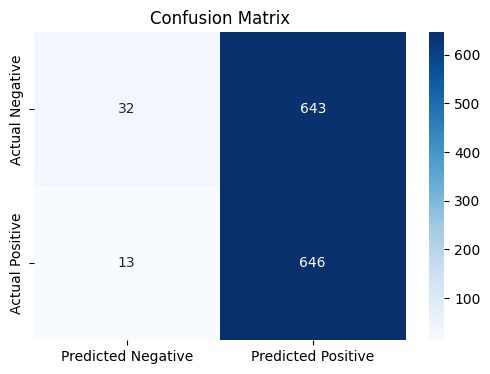

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Given values
tn, fp, fn, tp = 32, 643, 13, 646

# Create confusion matrix
cm = np.array([[tn, fp],
               [fn, tp]])

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix")
plt.show()


In [49]:
import os
len(os.listdir('/home/jupyter-nafisha/X-ray/Inference_data/Chexpert'))

4668